# Last Text Archive — Analysis Gallery

A **menu of analyses** for our class prototype. Each section below is
self-contained: a short plain-language question, one chart, and a takeaway.
Scroll through, and pick the ones that feel most meaningful to present.

**A few intentions baked in** (in the spirit of the class):
- We show **individual variation**, not just one "average person" — there is no
  single normal way to text.
- We treat the **self-reported feelings as the ground truth of lived
  experience.** When a sentiment model disagrees with a person, we read that as
  the *model* missing something, not the person being wrong.
- We avoid ranking each other. Difference here is interesting, not better/worse.

> Each chart is also saved as a PNG in `figures/` so they can drop straight
> into slides.


In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer

DATA = Path("data/lasttext_export.csv")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

# --- palette: matches the app's warm paper/ink look so slides feel cohesive ---
PAPER, INK, ACCENT, MUTED, LINE = "#f7f3ed", "#1a1816", "#b8462a", "#8a827b", "#d4c9b5"
WARM_COOL = ["#b8462a", "#c9763f", "#d6a25c", "#9aa873", "#5f7a6b", "#4a6b7a"]
mpl.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "savefig.facecolor": PAPER,
    "axes.edgecolor": LINE, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK, "ytick.color": INK, "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False, "savefig.bbox": "tight",
})

def load():
    df = pd.read_csv(DATA, parse_dates=["sent_at", "created_at"])
    # Recompute recency from sent_at. The stored days_since_sent is computed at
    # log-time (stale) and has one broken value — so we never use it.
    df["recency_days"] = (pd.Timestamp.now().normalize() - df["sent_at"]).dt.days
    # Strip redaction tokens like [name], [place] before any text analysis.
    df["message_clean"] = (
        df["message_text"].fillna("")
        .str.replace(r"\[[^\]]*\]", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True).str.strip()
    )
    return df

df = load()
print(f"{len(df)} entries from {df['user_name'].nunique()} people")
print(f"date range: {df['sent_at'].min().date()} to {df['sent_at'].max().date()}")


269 entries from 5 people
date range: 2025-01-02 to 2026-06-02


## 1 · The reply gap — who actually gets a response?

For texts we *received*, how often do we plan **not** to reply, broken out by
who sent it? Closeness is about the only thing that buys a reply.


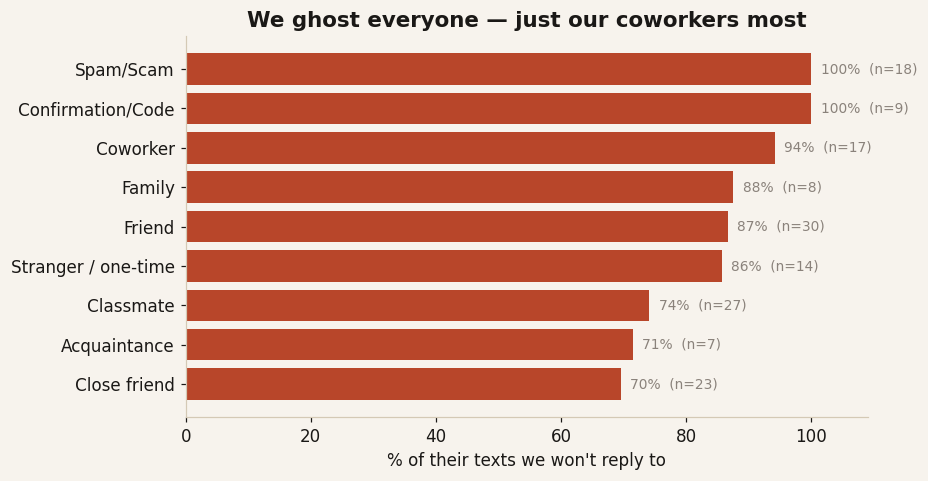

In [2]:
inc = df[(df.sender == "them") & df.intent_to_reply.notna()].copy()
inc["ignored"] = inc.intent_to_reply.eq("No")
g = inc.groupby("relation")["ignored"].agg(["mean", "size"])
g = g[g["size"] >= 5].sort_values("mean")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(g.index, g["mean"] * 100, color=ACCENT)
for y, (pct, n) in enumerate(zip(g["mean"] * 100, g["size"])):
    ax.text(pct + 1.5, y, f"{pct:.0f}%  (n={n})", va="center", fontsize=9, color=MUTED)
ax.set_xlim(0, 109); ax.set_xlabel("% of their texts we won't reply to")
ax.set_title("We ghost everyone — just our coworkers most")
plt.savefig(FIG / "1_reply_gap.png"); plt.show()


**Takeaway:** even our *closest friends'* last texts go unanswered a large share
of the time — and the rate climbs steadily as the relationship gets more
distant or transactional.


## 2 · Distance and feeling move together

Average emotional valence (1 = negative, 5 = positive) by relationship type.


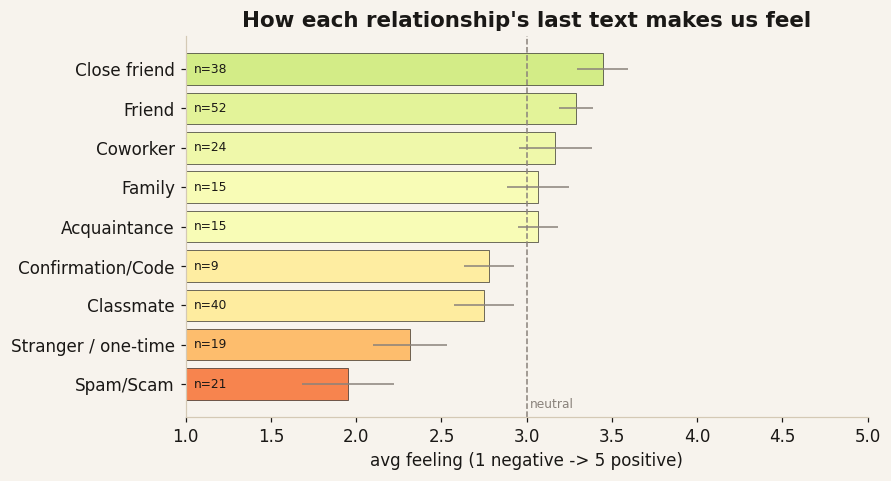

In [3]:
v = df.dropna(subset=["your_feeling_valence"]).groupby("relation")["your_feeling_valence"]
stat = v.agg(["mean", "std", "size"]); stat = stat[stat["size"] >= 4].sort_values("mean")
err = stat["std"] / np.sqrt(stat["size"])  # standard error

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [plt.cm.RdYlGn((m - 1) / 4) for m in stat["mean"]]
ax.barh(stat.index, stat["mean"], xerr=err, color=colors, edgecolor=INK, linewidth=0.4,
        error_kw=dict(ecolor=MUTED, lw=1))
ax.axvline(3, color=MUTED, ls="--", lw=1)
ax.text(3.02, -0.6, "neutral", color=MUTED, fontsize=8)
ax.set_xlim(1, 5); ax.set_xlabel("avg feeling (1 negative -> 5 positive)")
ax.set_title("How each relationship's last text makes us feel")
for y, n in enumerate(stat["size"]):
    ax.text(1.05, y, f"n={n}", va="center", fontsize=8, color=INK)
plt.savefig(FIG / "2_valence_gradient.png"); plt.show()


**Takeaway:** a clean gradient — closer ties feel warmer, transactional/unknown
contacts feel flat-to-negative. (Error bars = standard error; small-n groups
are noisier.)


## 3 · Evening is the warm part of the day

Average feeling by the time of day a text was sent.


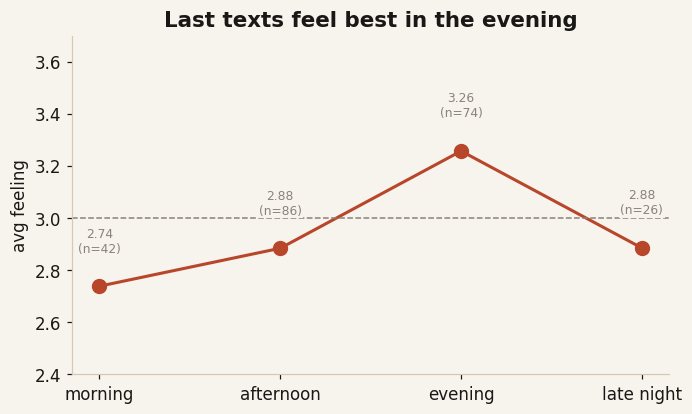

In [4]:
order = ["morning", "afternoon", "evening", "late_night"]
t = (df.dropna(subset=["your_feeling_valence", "sent_time_of_day"])
       .groupby("sent_time_of_day")["your_feeling_valence"].agg(["mean", "size"])
       .reindex(order).dropna())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(t)), t["mean"], "-o", color=ACCENT, lw=2, ms=9)
ax.axhline(3, color=MUTED, ls="--", lw=1)
ax.set_xticks(range(len(t)))
ax.set_xticklabels([x.replace("_", " ") for x in t.index])
ax.set_ylabel("avg feeling"); ax.set_ylim(2.4, 3.7)
ax.set_title("Last texts feel best in the evening")
bbox = dict(facecolor=PAPER, edgecolor="none", pad=1)
for i, (m, n) in enumerate(zip(t["mean"], t["size"])):
    ax.text(i, m + 0.12, f"{m:.2f}\n(n={int(n)})", ha="center", va="bottom",
            fontsize=8, color=MUTED, bbox=bbox)
plt.savefig(FIG / "3_time_of_day.png"); plt.show()


**Takeaway:** evening is the only window that clears neutral. Mornings are the bleakest.

## 4 · Does an NLP model "feel" the same things we do?

We run **VADER** (a sentiment model built for short, informal text) on the
message words alone, then compare its score to how the person *actually said*
they felt. Agreement would mean feeling is legible in the words; disagreement
means the model is missing the relationship and context a person carries.


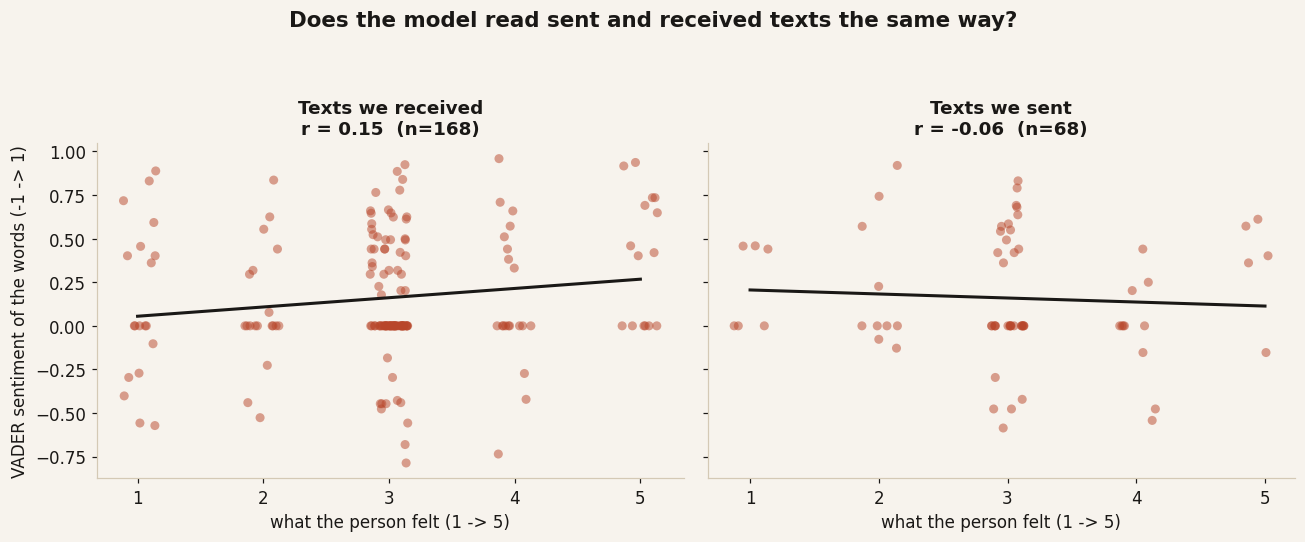

In [5]:
sid = SentimentIntensityAnalyzer()
df["vader"] = df["message_clean"].map(
    lambda t: sid.polarity_scores(t)["compound"] if isinstance(t, str) and t else np.nan)

rng = np.random.default_rng(0)
panels = [("them", "Texts we received"), ("me", "Texts we sent")]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (snd, title) in zip(axes, panels):
    s = df[(df.sender == snd)].dropna(subset=["vader", "your_feeling_valence"])
    r = s["vader"].corr(s["your_feeling_valence"])
    jit = s["your_feeling_valence"] + rng.uniform(-0.15, 0.15, len(s))
    ax.scatter(jit, s["vader"], alpha=0.5, color=ACCENT, edgecolor="none", s=35)
    if len(s) > 1:
        m, b = np.polyfit(s["your_feeling_valence"], s["vader"], 1)
        xs = np.array([1, 5]); ax.plot(xs, m * xs + b, color=INK, lw=2)
    ax.set_xlabel("what the person felt (1 -> 5)")
    ax.set_title(f"{title}\nr = {r:.2f}  (n={len(s)})", fontsize=12)
axes[0].set_ylabel("VADER sentiment of the words (-1 -> 1)")
fig.suptitle("Does the model read sent and received texts the same way?", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(FIG / "4_vader_vs_human.png"); plt.show()


**Takeaway:** the model **barely predicts our feelings either way** — the
correlations are weak and not statistically significant (received r≈0.14, sent
r≈−0.06). The same words ("ok", "sure", "lol") land completely differently
depending on who sent them and what came before. The clean methods point:
**a sentiment model can't recover feeling from the words of a text alone.**


## 5 · The words of texts we leave unanswered

The "will reply" group is too small (only ~22 messages) to compare vocabularies
reliably, so instead we look at the larger, robust group: the **126 texts we
received and don't plan to answer.** What do they tend to say?


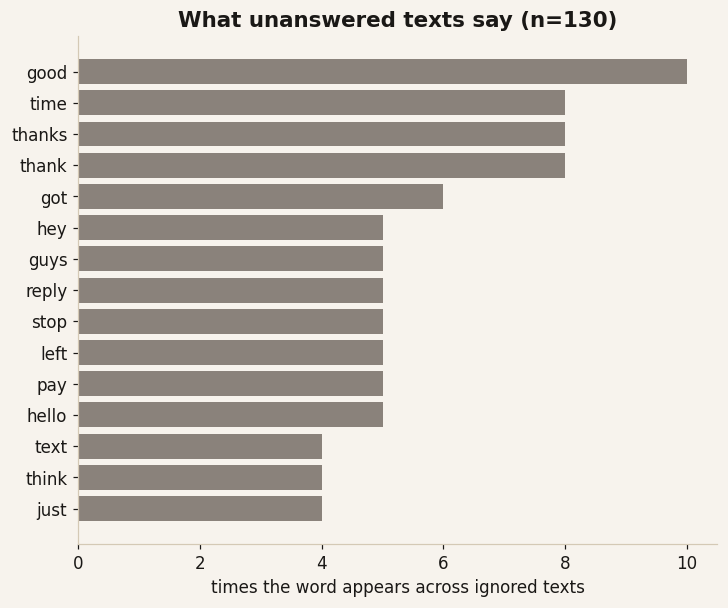

In [6]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
ign = df[(df.sender == "them") & df.intent_to_reply.eq("No")].copy()
# strip URLs and contraction fragments; keep letters-only words of 3+ chars
text5 = (ign.message_clean.str.replace(r"http\S+|www\.\S+", " ", regex=True)
                          .str.replace(r"['\u2019]", "", regex=True))
EXTRA = {"dont", "cant", "wont", "didnt", "doesnt", "im", "ive", "ill", "youre",
         "thats", "whats", "its", "were", "weve", "theyre", "gonna", "wanna",
         "yeah", "haha", "lol", "uw", "ur"}
stop = list(ENGLISH_STOP_WORDS.union(EXTRA))
vec = CountVectorizer(stop_words=stop, min_df=2, token_pattern=r"[a-z]{3,}")
X = vec.fit_transform(text5)
words = np.array(vec.get_feature_names_out())
counts = X.sum(0).A1
top = np.argsort(counts)[-15:]

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.barh(words[top], counts[top], color=MUTED)
ax.set_xlabel("times the word appears across ignored texts")
ax.set_title(f"What unanswered texts say (n={len(ign)})")
plt.savefig(FIG / "5_reply_words.png"); plt.show()


**Takeaway:** the everyday vocabulary of the texts that pile up unanswered —
mostly logistics and small talk. A robust word-frequency view over 126 messages.


## 6 · Each of us has a different emotional palette

Rather than asking "who feels best," we show the *mix* of feelings each person
records — everyone's last-text emotional world looks different.


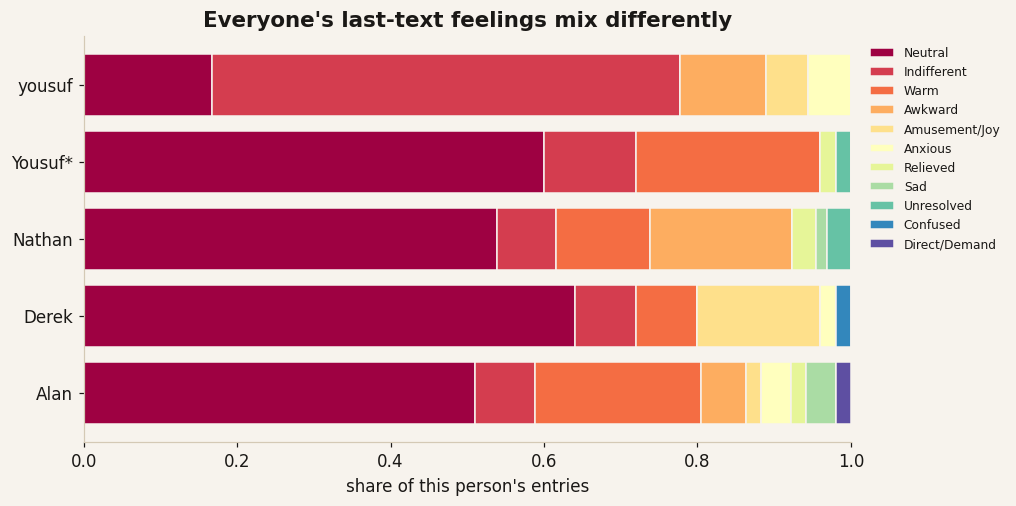

In [7]:
assert "your_feeling" in df.columns, "Re-run fetch_data.py to refresh the data first."
pal = (df.dropna(subset=["your_feeling"])
         .groupby(["user_name", "your_feeling"]).size().unstack(fill_value=0))
pal = pal.div(pal.sum(1), axis=0)  # row-normalize -> proportions
order = pal.sum().sort_values(ascending=False).index
pal = pal[order]

fig, ax = plt.subplots(figsize=(9, 4.8))
cmap = plt.cm.Spectral(np.linspace(0, 1, len(pal.columns)))  # distinct color per feeling
left = np.zeros(len(pal))
for i, feel in enumerate(pal.columns):
    ax.barh(pal.index, pal[feel], left=left, label=feel,
            color=cmap[i], edgecolor=PAPER, linewidth=1)
    left += pal[feel].values
ax.set_xlim(0, 1); ax.set_xlabel("share of this person's entries")
ax.set_title("Everyone's last-text feelings mix differently")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, frameon=False)
plt.savefig(FIG / "6_emotional_palette.png"); plt.show()


**Takeaway:** the same prompt produces genuinely different emotional portraits —
a direct visual argument against a single "normal." Great fit for the class
framing.


## 7 · The wall-of-text penalty

Does message length relate to how it feels? Bucketed by word count.


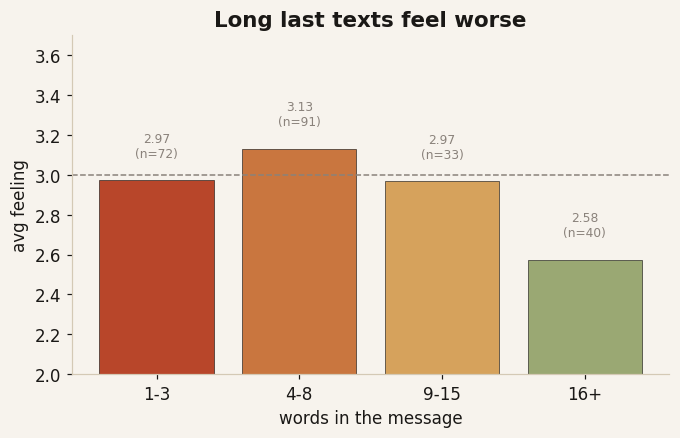

In [8]:
bins = [0, 3, 8, 15, 1000]; labels = ["1-3", "4-8", "9-15", "16+"]
d = df.dropna(subset=["your_feeling_valence"]).copy()
d["bucket"] = pd.cut(d.word_count, bins=bins, labels=labels)
w = d.groupby("bucket")["your_feeling_valence"].agg(["mean", "size"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(w.index.astype(str), w["mean"], color=WARM_COOL[:len(w)], edgecolor=INK, linewidth=0.4)
ax.axhline(3, color=MUTED, ls="--", lw=1); ax.set_ylim(2, 3.7)
ax.set_xlabel("words in the message"); ax.set_ylabel("avg feeling")
ax.set_title("Long last texts feel worse")
bbox = dict(facecolor=PAPER, edgecolor="none", pad=1)
for i, (m, n) in enumerate(zip(w["mean"], w["size"])):
    ax.text(i, m + 0.1, f"{m:.2f}\n(n={int(n)})", ha="center", va="bottom",
            fontsize=8, color=MUTED, bbox=bbox)
plt.savefig(FIG / "7_wall_of_text.png"); plt.show()


**Takeaway:** short and medium texts feel fine; 16+ word texts dip — the paragraph-length last message tends to carry bad news, conflict, or over-explanation.

## 8 · Tone is contagious

For texts we received, how their *apparent tone* relates to how *we* ended up
feeling. (Incoming only, where both are recorded.)


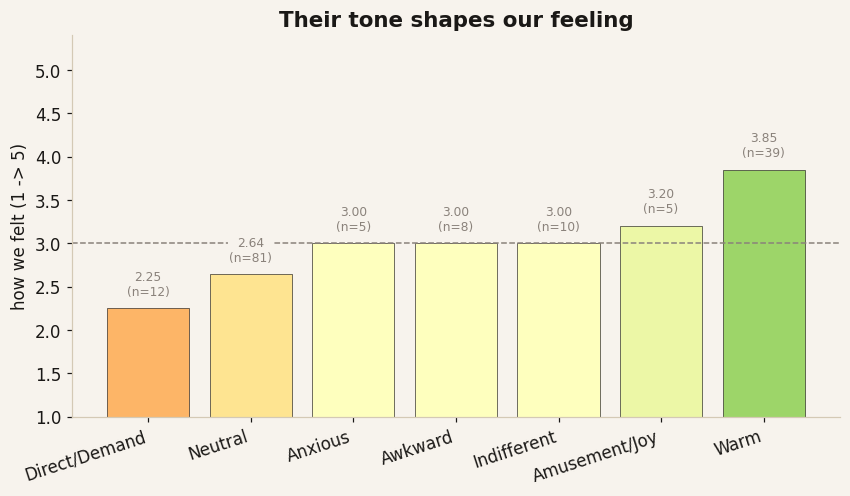

In [9]:
assert "their_tone" in df.columns, "Re-run fetch_data.py to refresh the data first."
c = (df[(df.sender == "them")].dropna(subset=["their_tone", "your_feeling_valence"])
       .groupby("their_tone")["your_feeling_valence"].agg(["mean", "size"]))
c = c[c["size"] >= 4].sort_values("mean")

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [plt.cm.RdYlGn((m - 1) / 4) for m in c["mean"]]
ax.bar(c.index, c["mean"], color=colors, edgecolor=INK, linewidth=0.4)
ax.axhline(3, color=MUTED, ls="--", lw=1); ax.set_ylim(1, 5.4)
ax.set_ylabel("how we felt (1 -> 5)"); ax.set_title("Their tone shapes our feeling")
ax.set_xticklabels(c.index, rotation=18, ha="right")
bbox = dict(facecolor=PAPER, edgecolor="none", pad=1)
for i, (m, n) in enumerate(zip(c["mean"], c["size"])):
    ax.text(i, m + 0.12, f"{m:.2f}\n(n={int(n)})", ha="center", va="bottom",
            fontsize=8, color=MUTED, bbox=bbox)
plt.savefig(FIG / "8_contagion.png"); plt.show()


**Takeaway:** a warm incoming message lifts the reader well above neutral; a
demanding one drags them below. Emotion transfers through the screen.


## 9 · Who goes silent first?

For each relationship, what share of our last texts were sent by **them** — i.e.
they reached out and *we* never replied?


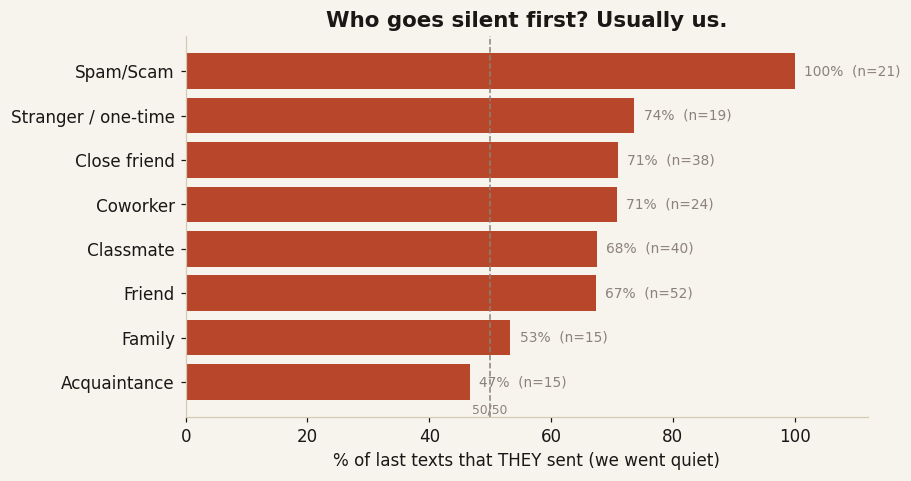

In [10]:
grp = df.groupby("relation")
sil = pd.DataFrame({"them": grp["sender"].apply(lambda x: (x == "them").mean() * 100),
                    "n": grp.size()})
sil = sil[sil["n"] >= 10].sort_values("them")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(sil.index, sil["them"], color=ACCENT)
ax.axvline(50, color=MUTED, ls="--", lw=1)
ax.text(50, -0.7, "50/50", color=MUTED, fontsize=8, ha="center")
ax.set_xlim(0, 112); ax.set_xlabel("% of last texts that THEY sent (we went quiet)")
ax.set_title("Who goes silent first? Usually us.")
for y, (p, n) in enumerate(zip(sil["them"], sil["n"])):
    ax.text(p + 1.5, y, f"{p:.0f}%  (n={int(n)})", va="center", fontsize=9, color=MUTED)
plt.savefig(FIG / "9_silent_first.png"); plt.show()


**Takeaway:** across almost every relationship it's *them* who sent the last,
unanswered message — we're usually the ones who let it drop. Family and
acquaintances are the most balanced.


## 10 · Closeness tracks feeling

Does how close we are to someone predict how their last text makes us feel? Each
dot is one message (jittered so they don't stack).


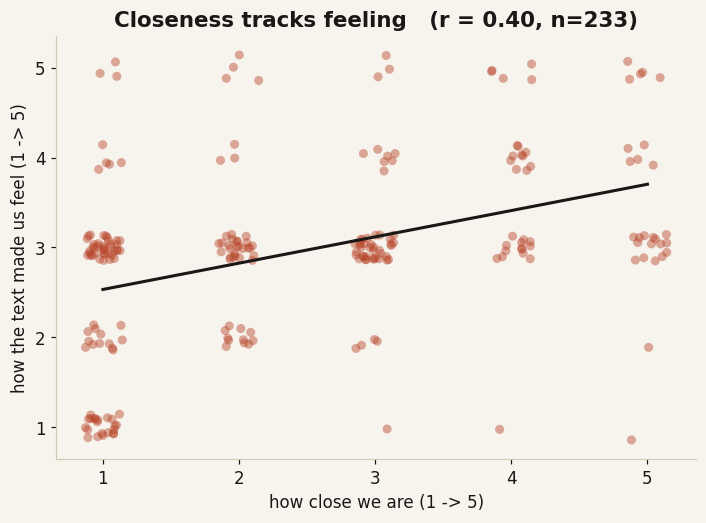

In [11]:
sub = df.dropna(subset=["closeness", "your_feeling_valence"])
r = sub["closeness"].corr(sub["your_feeling_valence"])
rng = np.random.default_rng(1)
jx = sub["closeness"] + rng.uniform(-0.15, 0.15, len(sub))
jy = sub["your_feeling_valence"] + rng.uniform(-0.15, 0.15, len(sub))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(jx, jy, alpha=0.45, color=ACCENT, edgecolor="none", s=35)
m, b = np.polyfit(sub["closeness"], sub["your_feeling_valence"], 1)
xs = np.array([1, 5]); ax.plot(xs, m * xs + b, color=INK, lw=2)
ax.set_xticks([1, 2, 3, 4, 5]); ax.set_yticks([1, 2, 3, 4, 5])
ax.set_xlabel("how close we are (1 -> 5)")
ax.set_ylabel("how the text made us feel (1 -> 5)")
ax.set_title(f"Closeness tracks feeling   (r = {r:.2f}, n={len(sub)})")
plt.savefig(FIG / "10_closeness_feeling.png"); plt.show()


**Takeaway:** a real, moderate relationship (r = 0.40) — the closer the person,
the better their last text tends to feel. Unlike the word-based model, *this*
signal is clearly there.


## 11 · What our last texts are about

The subjects our conversations tend to end on. Bar length = how many; color =
how good they feel (red negative, green positive).


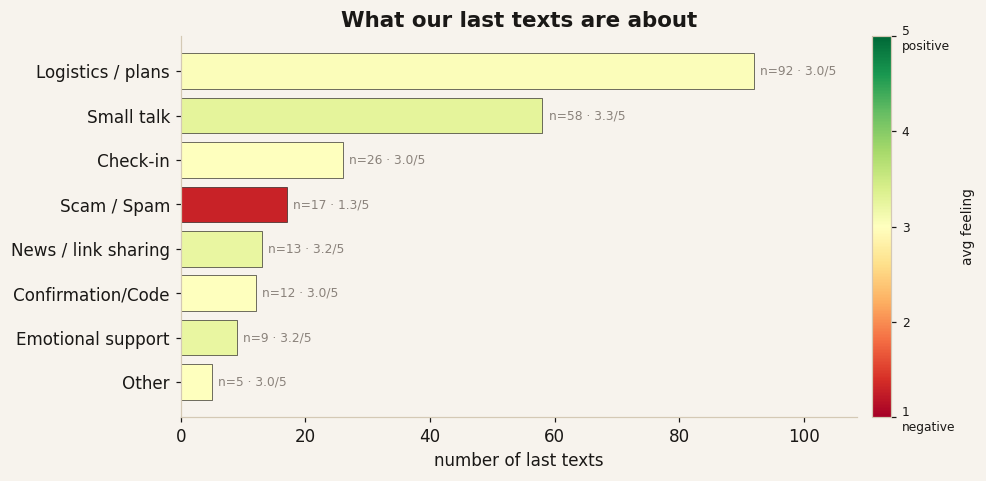

In [12]:
ct = df.dropna(subset=["your_feeling_valence"]).groupby("conversation_topic")["your_feeling_valence"].agg(["mean", "size"])
ct = ct[ct["size"] >= 5].sort_values("size")

norm = mpl.colors.Normalize(vmin=1, vmax=5)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
colors = [plt.cm.RdYlGn(norm(m)) for m in ct["mean"]]
ax.barh(ct.index, ct["size"], color=colors, edgecolor=INK, linewidth=0.4)
ax.set_xlim(0, ct["size"].max() * 1.18)
ax.set_xlabel("number of last texts")
ax.set_title("What our last texts are about")
for y, (m, n) in enumerate(zip(ct["mean"], ct["size"])):
    ax.text(n + 1, y, f"n={int(n)} · {m:.1f}/5", va="center", fontsize=8, color=MUTED)

# color legend: a colorbar mapping bar color -> average feeling
sm = mpl.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label("avg feeling", fontsize=9)
cbar.set_ticks([1, 2, 3, 4, 5])
cbar.set_ticklabels(["1\nnegative", "2", "3", "4", "5\npositive"])
cbar.ax.tick_params(labelsize=8)
plt.savefig(FIG / "11_topics.png"); plt.show()


**Takeaway:** most conversations die mid-**logistics** or in small talk. Spam is
both common and the clear emotional low point.


## 12 · When conversations die

A grid of when our last texts were sent — day of week against time of day.
Darker = more conversations went quiet in that slot.


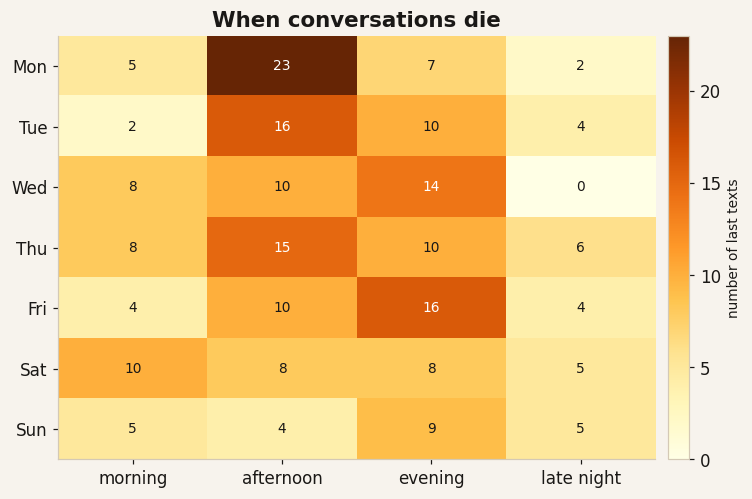

In [13]:
order_d = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]
order_t = ["morning", "afternoon", "evening", "late_night"]
ht = (pd.crosstab(df.sent_day_of_week, df.sent_time_of_day)
        .reindex(index=order_d, columns=order_t).fillna(0))

fig, ax = plt.subplots(figsize=(7.5, 5))
im = ax.imshow(ht.values, cmap="YlOrBr", aspect="auto")
ax.set_xticks(range(len(order_t))); ax.set_xticklabels([t.replace("_", " ") for t in order_t])
ax.set_yticks(range(len(order_d))); ax.set_yticklabels([d.capitalize() for d in order_d])
hi = ht.values.max()
for i in range(len(order_d)):
    for j in range(len(order_t)):
        v = int(ht.values[i, j])
        ax.text(j, i, v, ha="center", va="center", fontsize=9,
                color="white" if v > hi * 0.6 else INK)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label("number of last texts", fontsize=9)
ax.set_title("When conversations die")
plt.savefig(FIG / "12_when_die.png"); plt.show()


**Takeaway:** last texts pile up in the **afternoons**, with a clear Monday-
afternoon peak — conversations tend to fizzle during the daytime grind, not late
at night.


## 13 · How long our conversations have been dead

The median age of the last text for each relationship — how long since anyone
said anything.


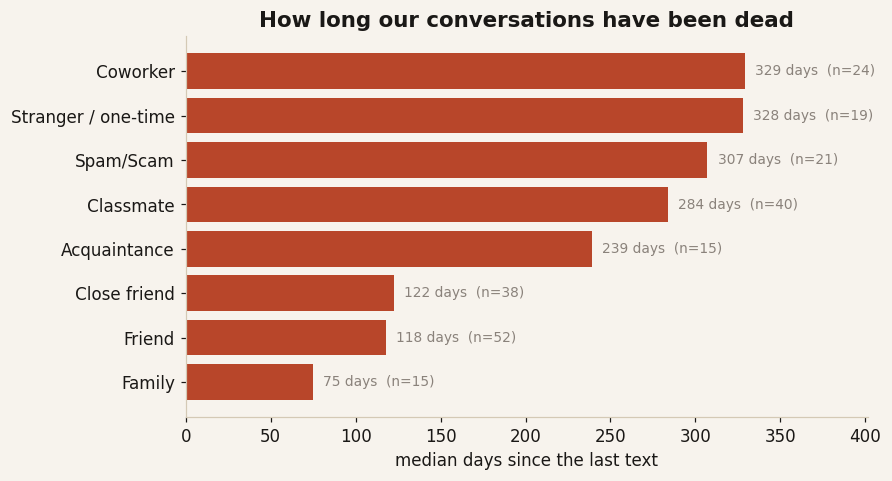

In [14]:
rec = df.groupby("relation")["recency_days"].agg(["median", "size"])
rec = rec[rec["size"] >= 10].sort_values("median")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(rec.index, rec["median"], color=ACCENT)
ax.set_xlim(0, rec["median"].max() * 1.22)
ax.set_xlabel("median days since the last text")
ax.set_title("How long our conversations have been dead")
for y, (m, n) in enumerate(zip(rec["median"], rec["size"])):
    ax.text(m + 6, y, f"{int(m)} days  (n={int(n)})", va="center", fontsize=9, color=MUTED)
plt.savefig(FIG / "13_dead_recency.png"); plt.show()


**Takeaway:** our **closest** silences are the most recent (friends ~4 months) —
still recoverable. The distant, transactional ones have been dead close to a
**year**. We let casual ties rot far longer than real ones.


## 14 · How we know the people we last texted

Where our contacts come from (bar length) and how their last texts feel (color,
red negative -> green positive).


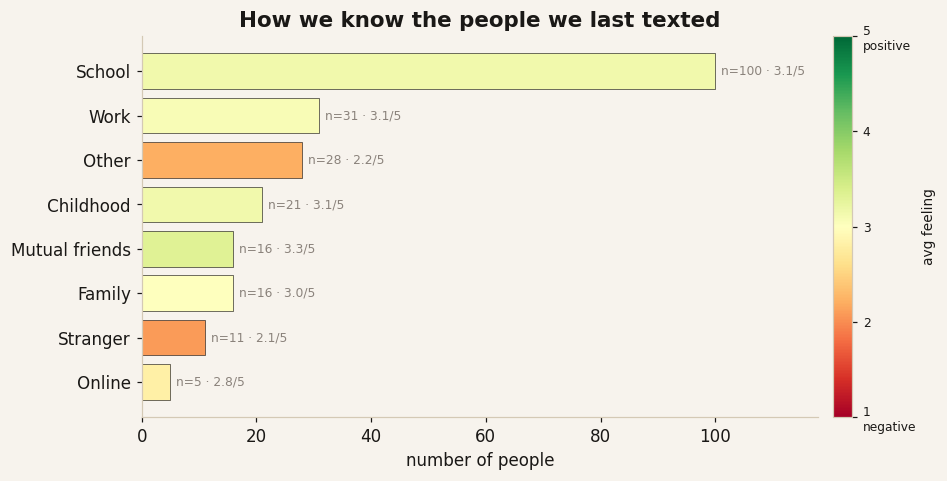

In [15]:
norm = mpl.colors.Normalize(vmin=1, vmax=5)
hk = df.dropna(subset=["your_feeling_valence"]).groupby("how_you_know")["your_feeling_valence"].agg(["mean", "size"])
hk = hk[hk["size"] >= 5].sort_values("size")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
colors = [plt.cm.RdYlGn(norm(m)) for m in hk["mean"]]
ax.barh(hk.index, hk["size"], color=colors, edgecolor=INK, linewidth=0.4)
ax.set_xlim(0, hk["size"].max() * 1.18)
ax.set_xlabel("number of people")
ax.set_title("How we know the people we last texted")
for y, (m, n) in enumerate(zip(hk["mean"], hk["size"])):
    ax.text(n + 1, y, f"n={int(n)} · {m:.1f}/5", va="center", fontsize=8, color=MUTED)
sm = mpl.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label("avg feeling", fontsize=9)
cbar.set_ticks([1, 2, 3, 4, 5]); cbar.set_ticklabels(["1\nnegative", "2", "3", "4", "5\npositive"])
cbar.ax.tick_params(labelsize=8)
plt.savefig(FIG / "14_how_known.png"); plt.show()


**Takeaway:** our last texts come overwhelmingly from **school**. Feeling tracks
how we know someone — people through **mutual friends** feel warmest, **strangers**
the coldest.

---

### Adding your own analysis
Copy any cell above, change the grouping column (`relation`, `life_domain`,
`conversation_topic`, `platform`, `contact_frequency`, `sender`...), and re-run.
Every chart auto-saves to `figures/`. To refresh the data, re-run
`python fetch_data.py` and restart the kernel.
